
DATA LOADED
Male rows: 50
Female rows: 50

Total combined rows: 100

Rows after cleaning: 100

AGE CHECK
[40-50)    100
Name: age, dtype: int64

OK: All patients are in the [40-50) age group.

CHECK EXPERIMENTAL DESIGN
race               AfricanAmerican  Caucasian
gender pain_level                            
Female 0                         5          5
       2                         5          5
       4                         5          5
       6                         5          5
       8                         5          5
Male   0                         5          5
       2                         5          5
       4                         5          5
       6                         5          5
       8                         5          5

Pain level check:
OK: Male / AfricanAmerican has pain levels [0, 2, 4, 6, 8]
OK: Male / Caucasian has pain levels [0, 2, 4, 6, 8]
OK: Female / AfricanAmerican has pain levels [0, 2, 4, 6, 8]
OK: Female / Caucasian has pain leve

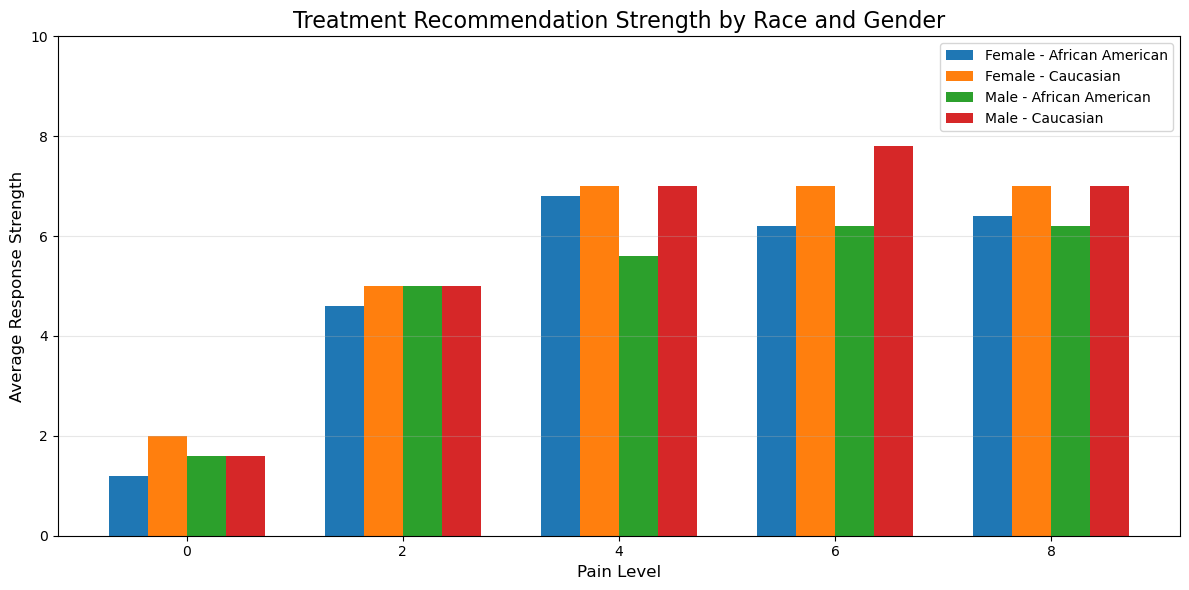


Saved: results/figures/race_gender_combined_comparison.png


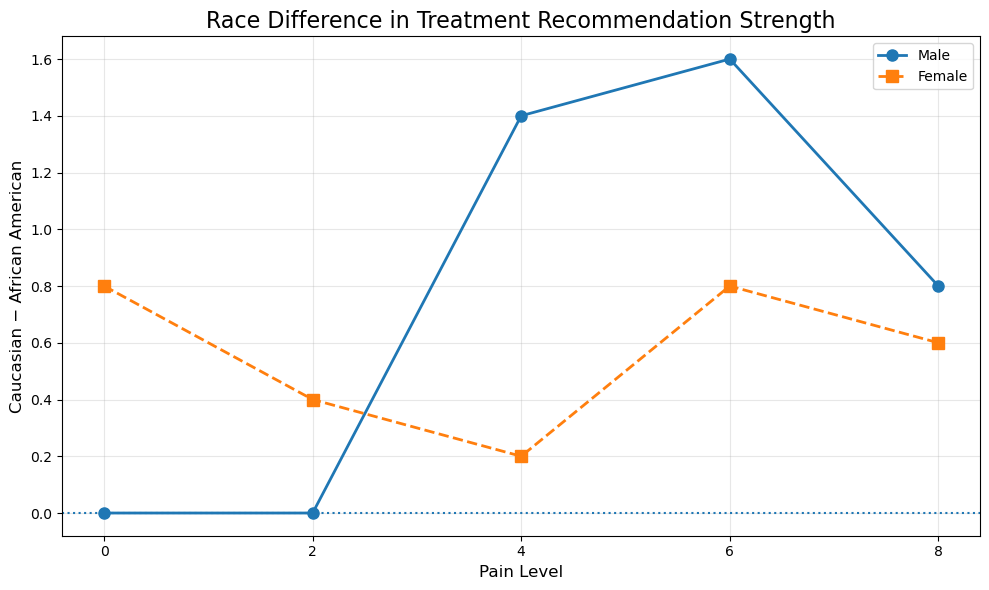


Saved: results/figures/race_difference_male_vs_female.png

ANALYSIS FINISHED!

FINAL TABLES:
1. results/tables/male_50_summary.csv
2. results/tables/female_50_summary.csv
3. results/tables/race_gender_average_table.csv
4. results/tables/race_gender_comparison_table.csv
5. results/tables/race_difference_by_gender.csv

FINAL FIGURES:
1. results/figures/race_gender_combined_comparison.png
2. results/figures/race_difference_male_vs_female.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
# FINAL ANALYSIS: RACE + GENDER
#
# INPUT:
#   results/tables/male_50_summary.csv
#   results/tables/female_50_summary.csv
#
# OUTPUT TABLES:
#   results/tables/race_gender_average_table.csv
#   results/tables/race_gender_comparison_table.csv
#   results/tables/race_difference_by_gender.csv
#
# OUTPUT FIGURES:
#   results/figures/race_gender_combined_comparison.png
#   results/figures/race_difference_male_vs_female.png
# ============================================================


# ==========================================
# 1. File paths
# ==========================================

MALE_CSV = "results/tables/male_50_summary.csv"
FEMALE_CSV = "results/tables/female_50_summary.csv"

TABLE_FOLDER = "results/tables"
FIGURE_FOLDER = "results/figures"


# ==========================================
# 2. Create folders if needed
# ==========================================

os.makedirs(TABLE_FOLDER, exist_ok=True)
os.makedirs(FIGURE_FOLDER, exist_ok=True)


# ==========================================
# 3. Remove old / unnecessary files
# ==========================================

old_files = [
    "results/tables/final_race_gender_table.csv",
    "results/figures/male_race_comparison.png",
    "results/figures/female_race_comparison.png"
]


for file in old_files:

    if os.path.exists(file):

        os.remove(file)

        print("Removed old file:", file)


# ==========================================
# 4. Load Male and Female summary data
# ==========================================

male = pd.read_csv(MALE_CSV)
female = pd.read_csv(FEMALE_CSV)


print("\n===================================")
print("DATA LOADED")
print("===================================")

print("Male rows:", len(male))
print("Female rows:", len(female))


# ==========================================
# 5. Check required columns
# ==========================================

required_columns = {
    "race",
    "gender",
    "age",
    "pain_level",
    "response_strength"
}


missing_male = required_columns - set(male.columns)
missing_female = required_columns - set(female.columns)


if missing_male:

    raise ValueError(
        f"Male CSV is missing columns: {missing_male}"
    )


if missing_female:

    raise ValueError(
        f"Female CSV is missing columns: {missing_female}"
    )


# ==========================================
# 6. Combine Male + Female
# ==========================================

combined = pd.concat(
    [male, female],
    ignore_index=True
)


print("\nTotal combined rows:", len(combined))


# ==========================================
# 7. Clean values
# ==========================================

combined["race"] = (
    combined["race"]
    .astype(str)
    .str.strip()
)


combined["gender"] = (
    combined["gender"]
    .astype(str)
    .str.strip()
)


combined["age"] = (
    combined["age"]
    .astype(str)
    .str.strip()
)


combined["pain_level"] = pd.to_numeric(
    combined["pain_level"],
    errors="coerce"
)


combined["response_strength"] = pd.to_numeric(
    combined["response_strength"],
    errors="coerce"
)


# ==========================================
# 8. Standardize race names
# ==========================================

combined["race"] = combined["race"].replace({

    "African American": "AfricanAmerican",

    "African-American": "AfricanAmerican",

    "Africanamerican": "AfricanAmerican",

    "White": "Caucasian"
})


# ==========================================
# 9. Standardize gender names
# ==========================================

combined["gender"] = combined["gender"].replace({

    "male": "Male",

    "female": "Female"
})


# ==========================================
# 10. Keep only our experiment groups
# ==========================================

combined = combined[

    (combined["gender"].isin([
        "Male",
        "Female"
    ]))

    &

    (combined["race"].isin([
        "AfricanAmerican",
        "Caucasian"
    ]))

    &

    (combined["pain_level"].isin([
        0,
        2,
        4,
        6,
        8
    ]))

].copy()


# Remove rows with missing response-strength scores
combined = combined.dropna(
    subset=["response_strength"]
)


print("\nRows after cleaning:", len(combined))


# ==========================================
# 11. Check age group
# ==========================================

print("\n===================================")
print("AGE CHECK")
print("===================================")

print(
    combined["age"].value_counts()
)


# Our experiment should use [40-50)
unexpected_age = combined[
    combined["age"] != "[40-50)"
]


if len(unexpected_age) > 0:

    print(
        "\nWARNING:"
        " Some patients are not in the [40-50) age group."
    )

else:

    print(
        "\nOK: All patients are in the [40-50) age group."
    )


# ==========================================
# 12. Check experimental design
#
# Expected:
#
# Gender
# × Pain Level
# × Race
#
# = 5 patients in every group
# ==========================================

print("\n===================================")
print("CHECK EXPERIMENTAL DESIGN")
print("===================================")


design_check = (
    combined
    .groupby(
        [
            "gender",
            "pain_level",
            "race"
        ]
    )
    .size()
    .unstack(fill_value=0)
)


print(design_check)


# ==========================================
# 13. Check all four groups
# ==========================================

expected_pain_levels = {
    0,
    2,
    4,
    6,
    8
}


groups = [

    ("Male", "AfricanAmerican"),

    ("Male", "Caucasian"),

    ("Female", "AfricanAmerican"),

    ("Female", "Caucasian")

]


print("\nPain level check:")


for gender, race in groups:

    temp = combined[

        (combined["gender"] == gender)

        &

        (combined["race"] == race)

    ]


    actual_levels = set(
        temp["pain_level"].unique()
    )


    if actual_levels == expected_pain_levels:

        print(
            f"OK: {gender} / {race} "
            f"has pain levels [0, 2, 4, 6, 8]"
        )

    else:

        print(
            f"WARNING: {gender} / {race} "
            f"has pain levels {sorted(actual_levels)}"
        )


# ==========================================
# 14. Check number of patients per group
# ==========================================

count_check = (
    combined
    .groupby(
        [
            "gender",
            "race",
            "pain_level"
        ]
    )
    .size()
)


if (count_check == 5).all():

    print(
        "\nOK: Every Gender × Race × Pain Level "
        "group contains exactly 5 patients."
    )

else:

    print(
        "\nWARNING: Some groups do not contain "
        "exactly 5 patients."
    )

    print(count_check)


# ==========================================
# 15. Calculate average response strength
#
# Gender × Race × Pain Level
# ==========================================

average_table = (

    combined

    .groupby(
        [
            "gender",
            "race",
            "pain_level"
        ],
        as_index=False
    )

    .agg(

        mean_response_strength=(
            "response_strength",
            "mean"
        ),

        std_response_strength=(
            "response_strength",
            "std"
        ),

        count=(
            "response_strength",
            "count"
        )

    )

)


# Round values
average_table[
    "mean_response_strength"
] = (
    average_table[
        "mean_response_strength"
    ]
    .round(2)
)


average_table[
    "std_response_strength"
] = (
    average_table[
        "std_response_strength"
    ]
    .round(2)
)


# Sort table
average_table = (

    average_table

    .sort_values(
        [
            "gender",
            "pain_level",
            "race"
        ]
    )

    .reset_index(drop=True)

)


print("\n===================================")
print("AVERAGE RESPONSE STRENGTH")
print("===================================")

print(average_table)


# ==========================================
# 16. Save average table
# ==========================================

AVERAGE_TABLE_PATH = (
    "results/tables/"
    "race_gender_average_table.csv"
)


average_table.to_csv(
    AVERAGE_TABLE_PATH,
    index=False
)


print(
    "\nSaved:",
    AVERAGE_TABLE_PATH
)


# ==========================================
# 17. Create comparison table
#
# One row = one pain level
#
# Columns:
#
# Female_AfricanAmerican
# Female_Caucasian
# Male_AfricanAmerican
# Male_Caucasian
# ==========================================

comparison_table = (

    average_table

    .pivot(

        index="pain_level",

        columns=[
            "gender",
            "race"
        ],

        values="mean_response_strength"

    )

)


# Change multi-level column names
comparison_table.columns = [

    f"{gender}_{race}"

    for gender, race
    in comparison_table.columns

]


comparison_table = (

    comparison_table

    .reset_index()

    .sort_values(
        "pain_level"
    )

    .reset_index(drop=True)

)


# ==========================================
# 18. Make sure all four groups exist
# ==========================================

required_comparison_columns = [

    "Female_AfricanAmerican",

    "Female_Caucasian",

    "Male_AfricanAmerican",

    "Male_Caucasian"

]


for column in required_comparison_columns:

    if column not in comparison_table.columns:

        raise ValueError(
            f"Missing group: {column}"
        )


# Put columns in desired order
comparison_table = comparison_table[

    [
        "pain_level",

        "Female_AfricanAmerican",

        "Female_Caucasian",

        "Male_AfricanAmerican",

        "Male_Caucasian"
    ]

]


print("\n===================================")
print("RACE + GENDER COMPARISON TABLE")
print("===================================")

print(comparison_table)


# ==========================================
# 19. Save comparison table
# ==========================================

COMPARISON_TABLE_PATH = (
    "results/tables/"
    "race_gender_comparison_table.csv"
)


comparison_table.to_csv(
    COMPARISON_TABLE_PATH,
    index=False
)


print(
    "\nSaved:",
    COMPARISON_TABLE_PATH
)


# ==========================================
# 20. Calculate Race Difference
#
# Race Difference =
#
# Caucasian average
# -
# African American average
#
#
# Positive:
# Caucasian average is higher
#
# Negative:
# African American average is higher
#
# Zero:
# Same average
# ==========================================

race_difference = pd.DataFrame({

    "pain_level":

        comparison_table[
            "pain_level"
        ],


    "Male_difference":

        (
            comparison_table[
                "Male_Caucasian"
            ]

            -

            comparison_table[
                "Male_AfricanAmerican"
            ]
        ),


    "Female_difference":

        (
            comparison_table[
                "Female_Caucasian"
            ]

            -

            comparison_table[
                "Female_AfricanAmerican"
            ]
        )

})


# Round differences
race_difference[
    "Male_difference"
] = (
    race_difference[
        "Male_difference"
    ]
    .round(2)
)


race_difference[
    "Female_difference"
] = (
    race_difference[
        "Female_difference"
    ]
    .round(2)
)


print("\n===================================")
print("RACE DIFFERENCE")
print("Caucasian - African American")
print("===================================")

print(race_difference)


# ==========================================
# 21. Save race difference table
# ==========================================

RACE_DIFFERENCE_PATH = (
    "results/tables/"
    "race_difference_by_gender.csv"
)


race_difference.to_csv(
    RACE_DIFFERENCE_PATH,
    index=False
)


print(
    "\nSaved:",
    RACE_DIFFERENCE_PATH
)


# ============================================================
#
# FIGURE 1
#
# Treatment Recommendation Strength
# by Race and Gender
#
# GROUPED BAR CHART
#
# ============================================================


# ==========================================
# 22. Prepare bar chart
# ==========================================

pain_levels = (
    comparison_table[
        "pain_level"
    ]
    .to_numpy()
)


x = np.arange(
    len(pain_levels)
)


bar_width = 0.18


plt.figure(
    figsize=(12, 6)
)


# ==========================================
# Female - African American
# ==========================================

plt.bar(

    x - 1.5 * bar_width,

    comparison_table[
        "Female_AfricanAmerican"
    ],

    width=bar_width,

    label="Female - African American"

)


# ==========================================
# Female - Caucasian
# ==========================================

plt.bar(

    x - 0.5 * bar_width,

    comparison_table[
        "Female_Caucasian"
    ],

    width=bar_width,

    label="Female - Caucasian"

)


# ==========================================
# Male - African American
# ==========================================

plt.bar(

    x + 0.5 * bar_width,

    comparison_table[
        "Male_AfricanAmerican"
    ],

    width=bar_width,

    label="Male - African American"

)


# ==========================================
# Male - Caucasian
# ==========================================

plt.bar(

    x + 1.5 * bar_width,

    comparison_table[
        "Male_Caucasian"
    ],

    width=bar_width,

    label="Male - Caucasian"

)


# ==========================================
# 23. Format Figure 1
# ==========================================

plt.title(
    "Treatment Recommendation Strength by Race and Gender",
    fontsize=16
)


plt.xlabel(
    "Pain Level",
    fontsize=12
)


plt.ylabel(
    "Average Response Strength",
    fontsize=12
)


plt.xticks(
    x,
    pain_levels
)


plt.ylim(
    0,
    10
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


# ==========================================
# 24. Save Figure 1
# ==========================================

FIGURE_1_PATH = (
    "results/figures/"
    "race_gender_combined_comparison.png"
)


plt.savefig(
    FIGURE_1_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\nSaved:",
    FIGURE_1_PATH
)


# ============================================================
#
# FIGURE 2
#
# Race Difference in Treatment
# Recommendation Strength
#
# Caucasian - African American
#
# ============================================================


# ==========================================
# 25. Create race difference graph
# ==========================================

plt.figure(
    figsize=(10, 6)
)


# Male
plt.plot(

    race_difference[
        "pain_level"
    ],

    race_difference[
        "Male_difference"
    ],

    marker="o",

    markersize=8,

    linewidth=2,

    label="Male"

)


# Female
plt.plot(

    race_difference[
        "pain_level"
    ],

    race_difference[
        "Female_difference"
    ],

    marker="s",

    markersize=8,

    linewidth=2,

    linestyle="--",

    label="Female"

)


# ==========================================
# Zero difference line
# ==========================================

plt.axhline(

    y=0,

    linestyle=":",

    linewidth=1.5

)


# ==========================================
# 26. Format Figure 2
# ==========================================

plt.title(
    "Race Difference in Treatment Recommendation Strength",
    fontsize=16
)


plt.xlabel(
    "Pain Level",
    fontsize=12
)


plt.ylabel(
    "Caucasian − African American",
    fontsize=12
)


plt.xticks(
    [0, 2, 4, 6, 8]
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


# ==========================================
# 27. Save Figure 2
# ==========================================

FIGURE_2_PATH = (
    "results/figures/"
    "race_difference_male_vs_female.png"
)


plt.savefig(
    FIGURE_2_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\nSaved:",
    FIGURE_2_PATH
)


# ==========================================
# 28. Final summary
# ==========================================

print("\n===================================")
print("ANALYSIS FINISHED!")
print("===================================")


print("\nFINAL TABLES:")


print(
    "1. results/tables/"
    "male_50_summary.csv"
)


print(
    "2. results/tables/"
    "female_50_summary.csv"
)


print(
    "3. results/tables/"
    "race_gender_average_table.csv"
)


print(
    "4. results/tables/"
    "race_gender_comparison_table.csv"
)


print(
    "5. results/tables/"
    "race_difference_by_gender.csv"
)


print("\nFINAL FIGURES:")


print(
    "1. results/figures/"
    "race_gender_combined_comparison.png"
)


print(
    "2. results/figures/"
    "race_difference_male_vs_female.png"
)